In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Iteration 200, Error: 19.560933
Iteration 400, Error: 18.944946
Iteration 600, Error: 18.348442
Iteration 800, Error: 17.770803
Iteration 1000, Error: 17.211434
Iteration 1200, Error: 16.669755
Iteration 1400, Error: 16.145209
Iteration 1600, Error: 15.637252
Iteration 1800, Error: 15.145361
Iteration 2000, Error: 14.669027


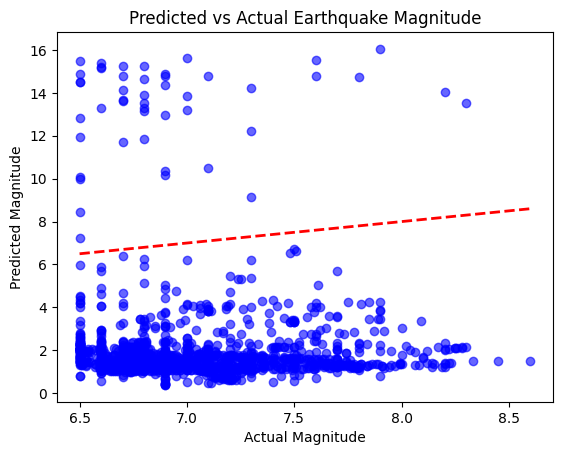

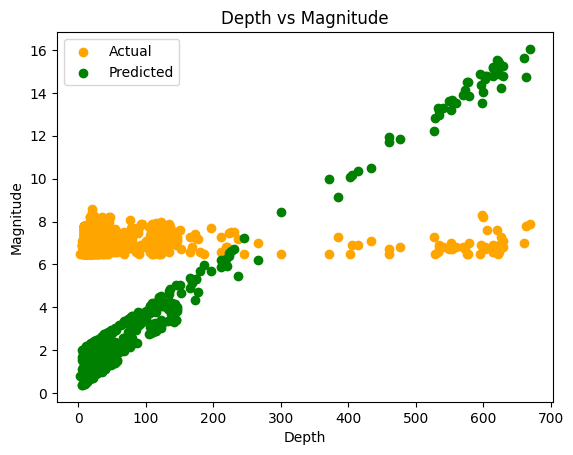

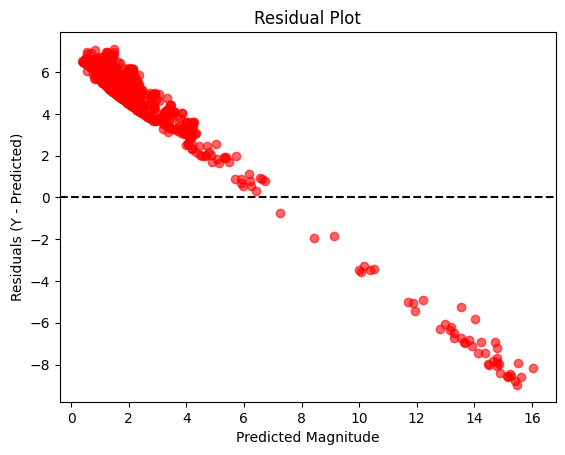

In [33]:

class EarthquakeAlerter:
    def __init__(self, iteration=1000, L_rate=0.005):
        self.iteration = iteration
        self.L_rate = L_rate

    def fit(self, X, Y, theta0=0):
        X = np.array(X)
        Y = np.array(Y)
        self.theta0 = theta0
        self.theta = np.zeros(X.shape[1])
        m = len(Y)

        for i in range(1, self.iteration + 1):
            self.hypo = X.dot(self.theta) + self.theta0
            error = (1 / (2 * m)) * np.sum((self.hypo - Y) ** 2)
            grad = (1 / m) * X.T.dot(self.hypo - Y)
            grad0 = (1 / m) * np.sum(self.hypo - Y)

            # Update parameters
            self.theta -= self.L_rate * grad
            self.theta0 -= self.L_rate * grad0

            if i % (self.iteration // 10) == 0:
                print(f"Iteration {i}, Error: {error:.6f}")

    def visualize(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
        preds = X.dot(self.theta) + self.theta0
    
        # Plot 1: Predicted vs Actual Magnitude
        plt.scatter(Y, preds, color='blue', alpha=0.6)
        plt.xlabel("Actual Magnitude")
        plt.ylabel("Predicted Magnitude")
        plt.title("Predicted vs Actual Earthquake Magnitude")
        plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)  # perfect line
        plt.show()
    
        # Plot 2: Depth vs Predicted Magnitude
        plt.scatter(X[:, 0], Y, color='orange', label='Actual')
        plt.scatter(X[:, 0], preds, color='green', label='Predicted')
        plt.xlabel("Depth")
        plt.ylabel("Magnitude")
        plt.title("Depth vs Magnitude")
        plt.legend()
        plt.show()
    
        # Plot 3: Residuals
        residuals = Y - preds
        plt.scatter(preds, residuals, color='red', alpha=0.6)
        plt.axhline(0, color='black', linestyle='--')
        plt.xlabel("Predicted Magnitude")
        plt.ylabel("Residuals (Y - Predicted)")
        plt.title("Residual Plot")
        plt.show()


if __name__ == "__main__":
    # Load dataset
    df = pd.read_csv("Dataset/earthquake_alert_balanced_dataset.csv")

    # Feature selection
    X = df[["depth", "sig"]]
    Y = df["magnitude"]

    # Train model
    model = EarthquakeAlerter(iteration=2000, L_rate=0.0001)
    model.fit(X, Y)

    # Visualize results
    model.visualize(X, Y)


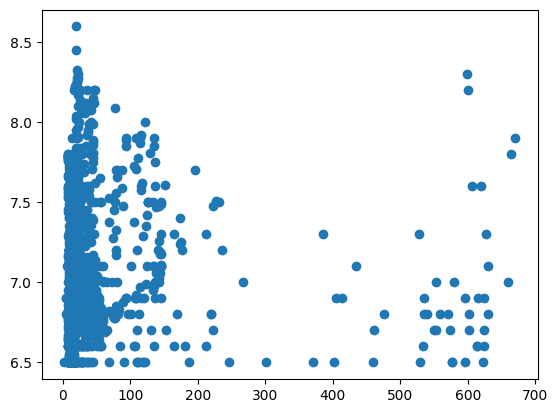

In [6]:
plt.scatter(df[""],df["magnitude"])
plt.show()